# Lab 4.06 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6 - Influence of background music on purchasing behaviour

Market research shows that background music in a supermarket can influence the purchasing behaviour of customers. A study compared three methods: no music, French chansons and Italian hits. In each case, the number of bottles of French, Italian and other wines sold was counted (Ryan, et al., 1998).

The research data can be found in the file data/MuziekWijn.csv.

1. Set up the correct crosstab.
2. Determine the marginal totals.
3. Determine the expected results.
4. Calculate the χ² test statistic.
5. Calculate Cramér's V. What can you conclude from this?

Visualize the data set:

1. Plot a bar chart showing the percentages of types of wine sold when no music was playing.
2. Plot a clustered bar chart of the dataset
3. Plot a bar chart (stacked bar chart) of the dataset

Results of the main calculations (rounded up to 3 decimal places):

* χ² ≈ 18.279
* Cramér's V ≈ 0.194

Read the dataset

In [2]:
df = pd.read_csv("../data/MuziekWijn.csv")

1. Set up the correct crosstab.

In [3]:
ct = pd.crosstab(df['Muziek'], df[' Wijn'])
print(ct)

 Wijn       Andere  Franse  Italiaanse
Muziek                                
Franse          35      39           1
Geen            43      30          11
Italiaanse      35      30          19


2. Determine the marginal totals.

In [4]:
mt = pd.crosstab(df['Muziek'], df[' Wijn'], margins=True)
print(mt)

 Wijn        Andere   Franse   Italiaanse  All
Muziek                                        
Franse           35       39            1   75
Geen             43       30           11   84
Italiaanse       35       30           19   84
All             113       99           31  243


3. Determine the expected results.

In [12]:
chi2, p, df, expected = stats.chi2_contingency(ct)
print(expected)

[[34.87654321 30.55555556  9.56790123]
 [39.0617284  34.22222222 10.71604938]
 [39.0617284  34.22222222 10.71604938]]


4. Calculate the χ² test statistic.

In [13]:
print(chi2)

18.279211510727354


5. Calculate Cramér's V. What can you conclude from this?

In [14]:
stats.contingency.association(ct.values, method='cramer')

0.19393696480652944

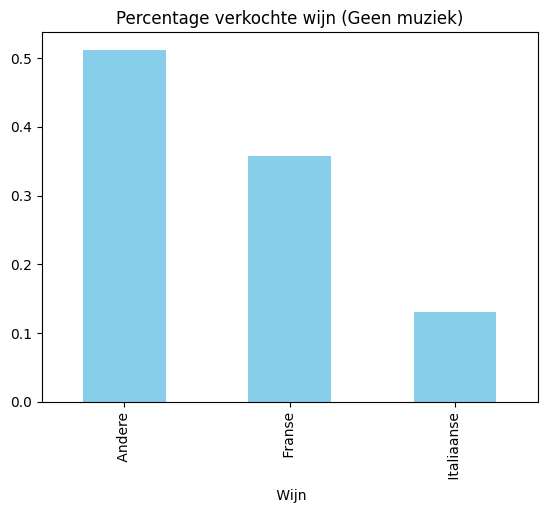

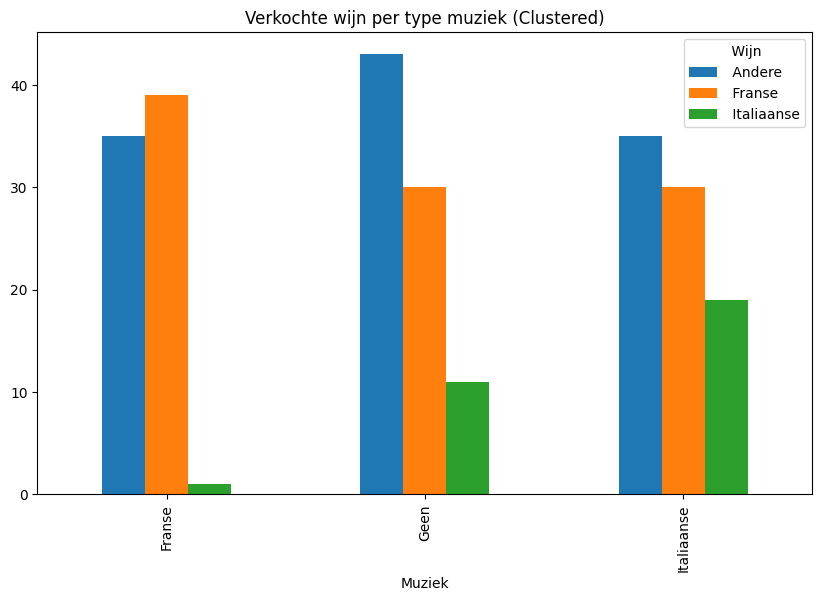

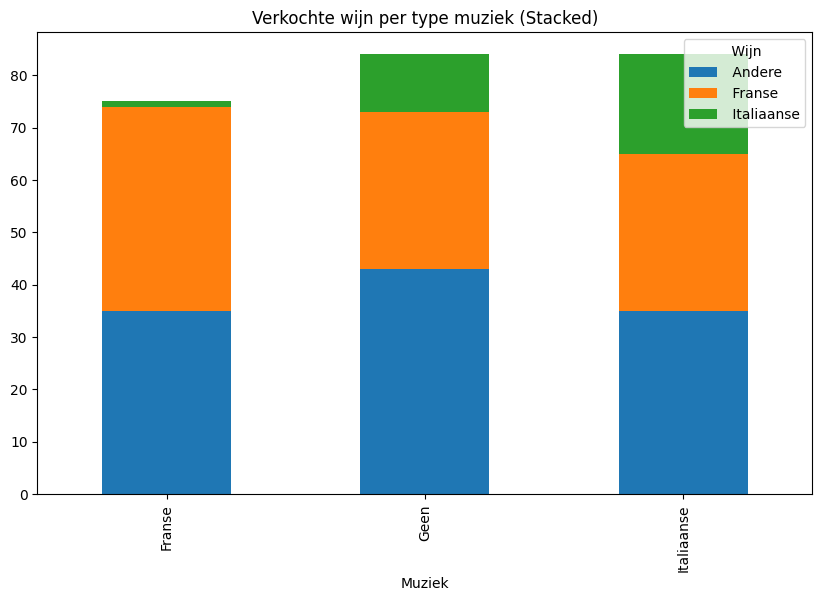

In [5]:
# 1. Bar chart: Percentages wijnsoort bij 'Geen muziek'
geen_muziek = ct.loc['Geen']
(geen_muziek / geen_muziek.sum()).plot(kind='bar', color='skyblue')
plt.title('Percentage verkochte wijn (Geen muziek)')
plt.show()

# 2. Clustered bar chart
ct.plot(kind='bar', figsize=(10, 6))
plt.title('Verkochte wijn per type muziek (Clustered)')
plt.show()

# 3. Stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Verkochte wijn per type muziek (Stacked)')
plt.show()